## Imports

In [1]:
from tmm.tmm_core import inc_tmm
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import curve_fit
from scipy.optimize import leastsq
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
data_dir = os.getcwd().replace('/TransferMatrix','') + '/data/20190702 P/'

data_1 = np.loadtxt(data_dir + '20190702P_1.CSV', delimiter=';')
data_1[:,1]/=100
data_2 = np.loadtxt(data_dir + '20190702P_2.CSV', delimiter=';')
data_2[:,1]/=100
data_3 = np.loadtxt(data_dir + '20190702P_3.CSV', delimiter=';')
data_3[:,1]/=100
data_background = np.loadtxt(data_dir + '20190702P_substrate.CSV', delimiter=';')
data_background[:,1]/=100

wafer_data = data_1

## Surface scattering

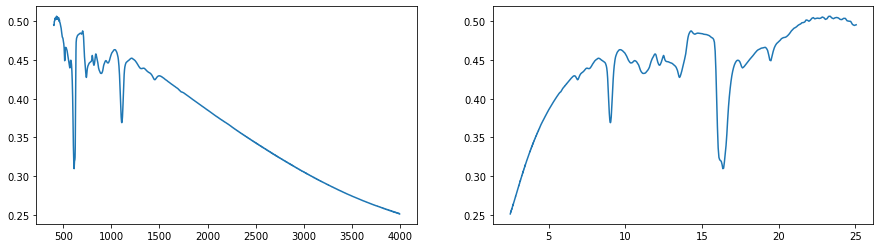

In [2]:
# Get T0
# Plot measurements and scattering functions    
wavenumbers = data_background[:,0]       # In cm-1
wavelengths = 1e4 * 1/wavenumbers             # In um

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,4))
ax1.plot(data_background[:,0], data_background[:,1])
ax2.plot(wavelengths, data_background[:,1])

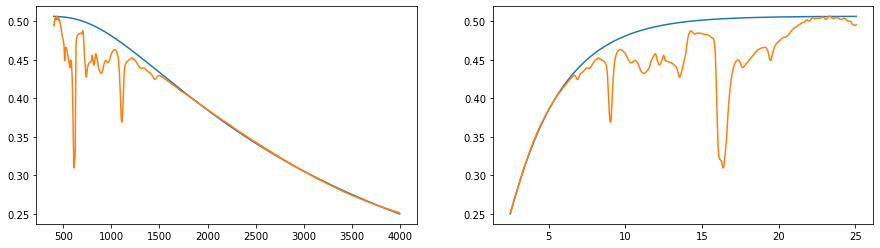

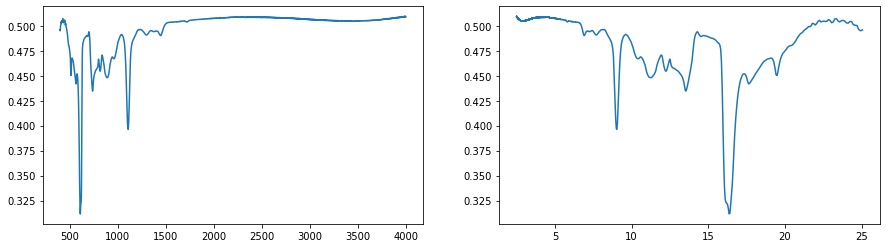

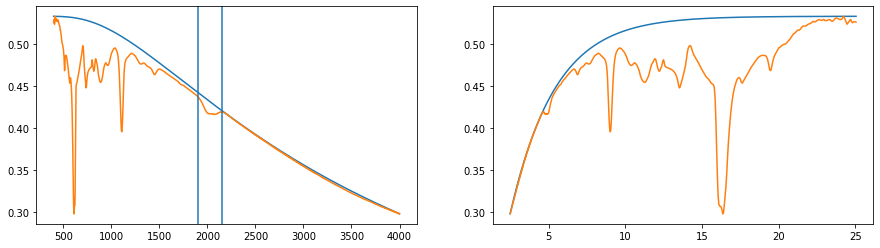

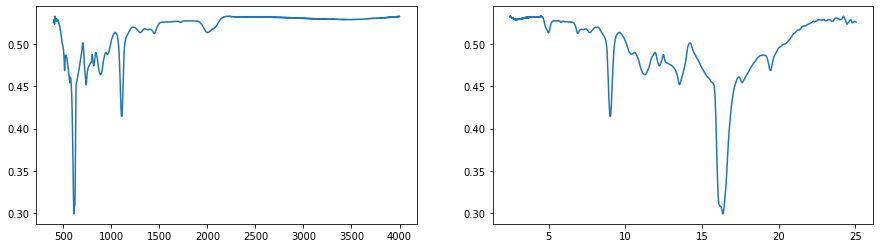

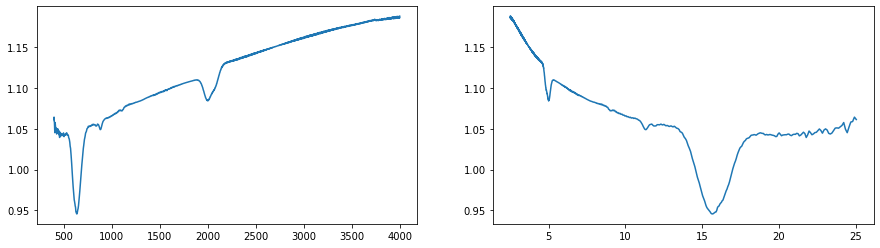

In [3]:
def scattering_T_model(wavelengths, a, b, c):
    return a * (1 - np.exp(-b*wavelengths**c))

def constrained_model(p, wavelengths, ydata):
    penalty = ydata - scattering_T_model(wavelengths, *p)
    penalty[penalty < 0] = 0
    return ydata - scattering_T_model(wavelengths, *p) +  1e2 *penalty

def scattering_T_fit(wavenumbers, Tdata):
    p0 = [np.amax(Tdata), 0.1, 1]
    bounds = ([np.amax(Tdata), 0, 0],[1, np.inf, np.inf])
    wavenumbers = data_background[:,0]
    wavelengths = 1e4 * 1/wavenumbers
    x = wavelengths[wavenumbers > 1550]
    y = Tdata[wavenumbers > 1550]
    spopt, spcov = curve_fit(scattering_T_model, x, y, p0=p0, bounds=bounds)
    return spopt

def scattering_T_fit_tot(wavenumbers, Tdata):
    p0 = [np.amax(Tdata), 0.1, 1]
    bounds = ([np.amax(Tdata), 0, 0],[1, np.inf, np.inf])
    wavenumbers = data_background[:,0]
    wavelengths = 1e4 * 1/wavenumbers
    fitting_range = np.logical_or(wavenumbers > 2150, np.logical_and(wavenumbers > 1550, wavenumbers < 1900))
    #fitting_range = wavenumbers > 2150
    x = wavelengths[fitting_range]
    y = Tdata[fitting_range]
    spopt, spcov = curve_fit(scattering_T_model, x, y, p0=p0, bounds=bounds)
    return spopt

def scattering_T_fit_tot_con(wavenumbers, Tdata):
    p0 = (np.amax(Tdata), 0.1, 1.)
    bounds = ([np.amax(Tdata), 0, 0],[1, np.inf, np.inf])
    wavenumbers = data_background[:,0]
    wavelengths = 1e4 * 1/wavenumbers
    fitting_range = np.logical_or(wavenumbers > 2150, np.logical_and(wavenumbers > 1550, wavenumbers < 1900))
    #fitting_range = wavenumbers > 2150
    x = wavelengths[fitting_range]
    y = Tdata[fitting_range]
    spopt = least_squares(constrained_model, p0, args=(x, y), bounds=bounds).x
    return spopt

# Fit c-Si substrate
spopt = scattering_T_fit(data_background[:,0], data_background[:,1])
def scattering_T(wavelengths): 
    return scattering_T_model(wavelengths, *spopt)/spopt[0]
        
# Plot measurements and scattering functions    
wavenumbers = data_background[:,0]       # In cm-1
wavelengths = 1e4 * 1/wavenumbers             # In um

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,4))
ax1.plot(wavenumbers, np.array(scattering_T(wavelengths)*spopt[0]))
ax1.plot(data_background[:,0], data_background[:,1])
ax2.plot(wavelengths, np.array(scattering_T(wavelengths)*spopt[0]))
ax2.plot(wavelengths, data_background[:,1])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,4))
ax1.plot(wavenumbers, data_background[:,1]/scattering_T(wavelengths))
ax2.plot(wavelengths, data_background[:,1]/scattering_T(wavelengths))

# Fit total wafer
spopt_tot = scattering_T_fit_tot_con(wafer_data[:,0], wafer_data[:,1])
def scattering_T_tot(wavelengths): 
    return scattering_T_model(wavelengths, *spopt_tot)/spopt_tot[0]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,4))
ax1.plot(wavenumbers, np.array(scattering_T_tot(wavelengths)*spopt_tot[0]))
ax1.plot(wafer_data[:,0], wafer_data[:,1])
ax2.plot(wavelengths, np.array(scattering_T_tot(wavelengths)*spopt_tot[0]))
ax2.plot(wavelengths, wafer_data[:,1])
ax1.axvline(1900)
ax1.axvline(2150)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,4))
ax1.plot(wavenumbers, wafer_data[:,1]/scattering_T_tot(wavelengths))
ax2.plot(wavelengths, wafer_data[:,1]/scattering_T_tot(wavelengths))


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,4))
ax1.plot(wafer_data[:,0], wafer_data[:,1]/data_background[:,1])
ax2.plot(wavelengths, wafer_data[:,1]/data_background[:,1])

## Define materials

In [3]:
## SiO2
SiO2_n_data_1 = np.loadtxt(os.getcwd() + '/materials/' + 'SiO2_n_1.txt', delimiter=',')
SiO2_k_data_1 = np.loadtxt(os.getcwd() + '/materials/' + 'SiO2_k_1.txt', delimiter=',')
SiO2_n_data_2 = np.loadtxt(os.getcwd() + '/materials/' + 'SiO2_n_2.csv', delimiter=',')
SiO2_k_data_2 = np.loadtxt(os.getcwd() + '/materials/' + 'SiO2_k_2.csv', delimiter=',')

SiO2_n_1 =  interp1d(SiO2_n_data_1[:,0], SiO2_n_data_1[:,1]) # Kischkat 2012, 1.54 - 14.3 um
SiO2_k_1 =  interp1d(SiO2_k_data_1[:,0], SiO2_k_data_1[:,1]) # Kischkat 2012
SiO2_n_2 =  interp1d(SiO2_n_data_2[:,0], SiO2_n_data_2[:,1]) # Popova 1972, 7 - 50 um
SiO2_k_2 =  interp1d(SiO2_k_data_2[:,0], SiO2_k_data_2[:,1]) # Popova 1972

def SiO2_n(wavelength):
    if wavelength < 14.285 and wavelength >= 7:
        return (SiO2_n_1(wavelength) + SiO2_n_2(wavelength)) / 2
    elif wavelength < 7:
        return SiO2_n_1(wavelength)
    else: 
        return SiO2_n_2(wavelength)
    
def SiO2_k(wavelength):
    if wavelength < 14.285 and wavelength >= 7:
        return (SiO2_k_1(wavelength) + SiO2_k_2(wavelength)) / 2
    elif wavelength < 7:
        return SiO2_k_1(wavelength)
    else: 
        return SiO2_k_2(wavelength)  
    
## Si substrate, Edwards and Ochoa 1980
Si_n = lambda x : 3.41983+0.159906/(x**2-0.028)-0.123109*(1/(x**2-0.028))**2+1.26878*10**-6*x**2-1.95104*10**-9*x**4

## All simulations with n from literature, zero k

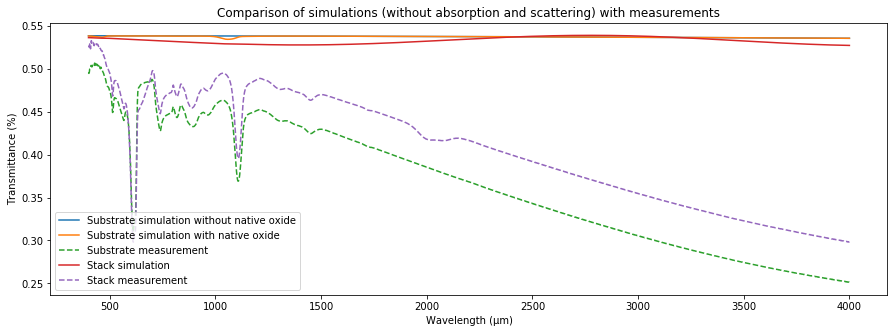

In [27]:
wafer_data = data_1

def t_sub_nok(wavelengths):
    c_list = ['i','i','i']
    d_list = [np.inf, 525, np.inf] 
    T_list = []
                                 
    for i, wavelength in enumerate(wavelengths):
        Si = np.complex(Si_n(wavelength), 0)
        n_list = [1, Si, 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'])
    return T_list

fig, ax = plt.subplots(figsize = (15,5))
ax.plot(1e4* 1/wavelengths, t_sub_nok(wavelengths), label='Substrate simulation without native oxide')
ax.set_title("Comparison of simulations (without absorption and scattering) with measurements")
ax.set_xlabel(r'Wavelength (μm)')
ax.set_ylabel('Transmittance (%)')

# Simulate Substrate + Oxide layer
def t_sub_ox_nok(wavelengths):
    c_list = ['i','c','i','i']
    
    d_list = [np.inf, 0.002, 525, np.inf] 
    T_list = []
                                 
    for i, wavelength in enumerate(wavelengths):
        SiO2 = np.complex(SiO2_n(wavelength), SiO2_k(wavelength))
        Si = np.complex(Si_n(wavelength), 0)
        n_list = [1, SiO2, Si, 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'])
    return T_list

ax.plot(data_background[:,0], t_sub_ox_nok(1e4* 1/data_background[:,0]), label='Substrate simulation with native oxide')
ax.plot(data_background[:,0], data_background[:,1], label = 'Substrate measurement', linestyle = '--')

# Simulate Total stack
def t_total_nok(wavelengths):
    c_list = ['i','c','c','i','i']
    
    # 100C: 253, 250C: 238, 350: 261
    d_list = [np.inf, 0.550, 0.002, 525, np.inf] 
    T_list = []
                                 
    for i, wavelength in enumerate(wavelengths):
        Si = np.complex(3.42, 0)
        SiO2 = np.complex(SiO2_n(wavelength), 0)
        n_list = [1, 3.5, SiO2, Si, 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'] )
    return T_list

ax.plot(wafer_data[:,0], t_total_nok(1e4* 1/wafer_data[:,0]), label='Stack simulation')
ax.plot(wafer_data[:,0], wafer_data[:,1], label = 'Stack measurement', linestyle = '--')
ax.legend()
#1e4* 1/wafer_data[:,0]

## Substrate

### Scattering 

In [6]:
np.amax(data_background[:,1]/t_sub_nok(1e4* 1/data_background[:,0]))

0.9407429783987092

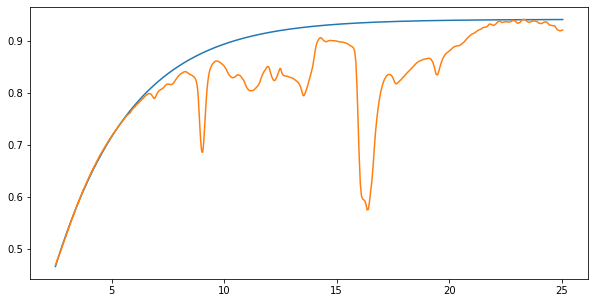

In [7]:
def scattering_T_model(wavelengths, a, b, c):
    return a * (1 - np.exp(-b*wavelengths**c))

def scattering_T_fit(wavenumbers, Tdata):
    p0 = [np.amax(Tdata), 0.1, 1]
    bounds = ([np.amax(Tdata), 0, 0],[1, np.inf, np.inf])
    wavenumbers = data_background[:,0]
    wavelengths = 1e4 * 1/wavenumbers
    x = wavelengths[wavenumbers > 1550]
    y = Tdata[wavenumbers > 1550]
    spopt, spcov = curve_fit(scattering_T_model, x, y, p0=p0, bounds=bounds)
    return spopt

y = data_background[:,1]/t_sub_nok(1e4* 1/data_background[:,0])
x = 1e4* 1/data_background[:,0]
# Fit c-Si substrate
spopt = scattering_T_fit(x, y)
def scattering_T(wavelengths): 
    return scattering_T_model(wavelengths, *spopt)

# Plot scattering curve: ratio of measured data to simulated data
fig, ax = plt.subplots(figsize = (10,5))
ax.plot(1e4* 1/data_background[:,0], scattering_T(1e4* 1/data_background[:,0]), label='simulation with k = 0')
ax.plot(1e4* 1/data_background[:,0], data_background[:,1]/t_sub_nok(1e4* 1/data_background[:,0]), label='simulation with k = 0')

In [8]:
# Extract substrate k
c_list = ['i','i','i']
d_list = [np.inf, 525, np.inf] 
def t_sub_k(wavelength, k):  
    Si = np.complex(Si_n(wavelength), k)
    n_list = [1, Si, 1]
    T = inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'] * scattering_T(wavelength)
    return T

transmission_data = data_background[:,1]
wavenumbers = data_background[:,0]
wavelengths = 1e4 * 1/wavenumbers

Si_ks = np.array([])
bounds = ([0],[np.inf])
for i, wavelength in enumerate(wavelengths):
    p0 = [0.001]
    popt, pcov = curve_fit(t_sub_k, wavelength, transmission_data[i], p0=p0, bounds=bounds)
    Si_ks = np.append(Si_ks, popt)
    
Si_k = interp1d(wavelengths, Si_ks)

/Users/bruno/.virtualenvs/thesis/lib/python3.7/site-packages/scipy/optimize/minpack.py:799: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


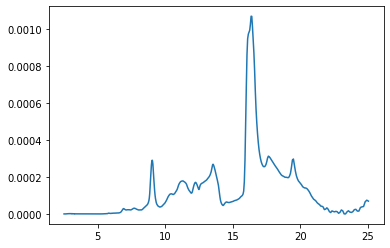

In [9]:
plt.plot(wavelengths, Si_k(wavelengths))

### Simulate

Text(0, 0.5, 'Transmittance (%)')

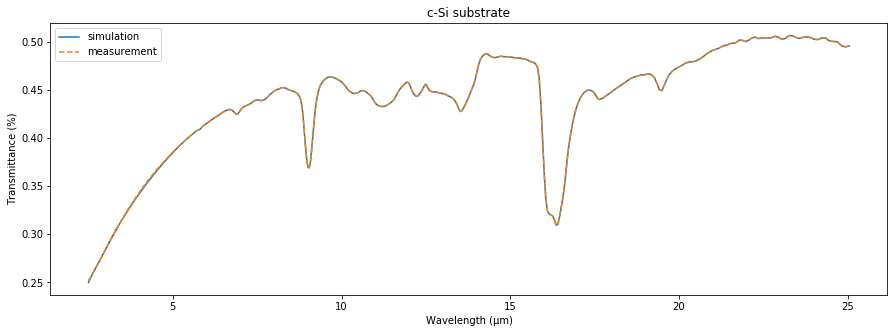

In [10]:
# Simulate substrate
c_list = ['i','i','i']
d_list = [np.inf, 525, np.inf] 
def t_sub(wavelengths):
    T_list = []
                                 
    for i, wavelength in enumerate(wavelengths):
        Si = np.complex(Si_n(wavelength), Si_k(wavelength))
        n_list = [1, Si, 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'] * scattering_T(wavelength))
    return T_list

fig, ax = plt.subplots(figsize = (15,5))
ax.plot(wavelengths, t_sub(wavelengths), label='simulation')
ax.plot(1e4*1/data_background[:,0], data_background[:,1], label = 'measurement', linestyle = '--')
ax.legend()
ax.set_title("c-Si substrate")
ax.set_xlabel(r'Wavelength (μm)')
ax.set_ylabel('Transmittance (%)')

## Total stack

In [11]:
wafer_data = data_1

In [12]:
np.amax(wafer_data[:,1]/t_total_nok(1e4* 1/wafer_data[:,0]))

0.9893692820299921

### Fit scattering of total stack

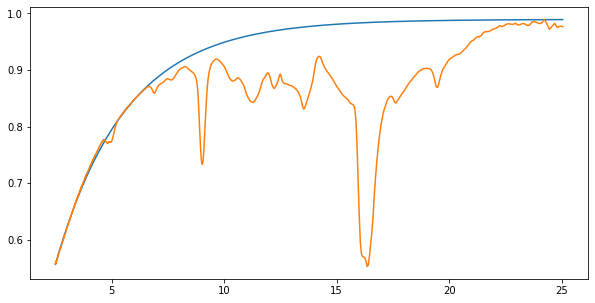

In [13]:
def scattering_T_model(wavelengths, a, b, c):
    return a * (1 - np.exp(-b*wavelengths**c))

def scattering_T_fit_tot(wavenumbers, Tdata):
    p0 = [np.amax(Tdata), 0.1, 1]
    bounds = ([np.amax(Tdata), 0, 0],[1, np.inf, np.inf])
    wavenumbers = data_background[:,0]
    wavelengths = 1e4 * 1/wavenumbers
    x = wavelengths[wavenumbers > 1550]
    y = Tdata[wavenumbers > 1550]
    spopt, spcov = curve_fit(scattering_T_model, x, y, p0=p0, bounds=bounds)
    return spopt

y = wafer_data[:,1]/t_total_nok(1e4* 1/wafer_data[:,0])
x = 1e4* 1/data_background[:,0]
# Fit c-Si substrate
spopt_tot = scattering_T_fit_tot(x, y)
def scattering_T_tot(wavelengths): 
    return scattering_T_model(wavelengths, *spopt_tot)

# Plot scattering curve: ratio of measured data to simulated data
fig, ax = plt.subplots(figsize = (10,5))
ax.plot(1e4* 1/wafer_data[:,0], scattering_T_tot(1e4* 1/wafer_data[:,0]), label='simulation with k = 0')
ax.plot(1e4* 1/wafer_data[:,0], wafer_data[:,1]/t_total_nok(1e4* 1/wafer_data[:,0]), label='simulation with k = 0')

## Simulate total stack

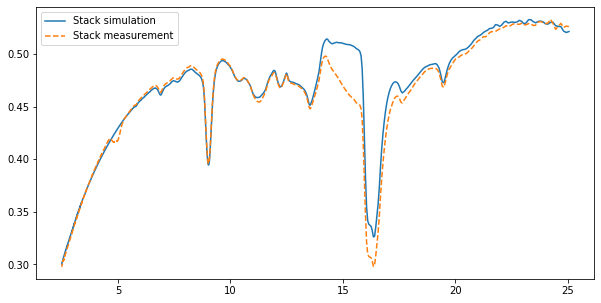

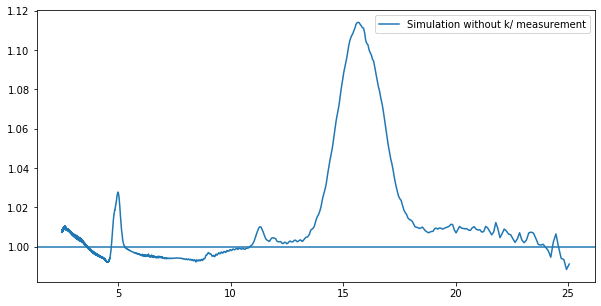

In [21]:
# Simulate Total stack
c_list = ['i','c', 'i','i']
d_list = [np.inf, 0.246, 525, np.inf] 
def t_total(wavelengths):    
    # 100C: 253, 250C: 238, 350: 261
    T_list = []
    for i, wavelength in enumerate(wavelengths):
        Si = np.complex(Si_n(wavelength), Si_k(wavelength))
        n_list = [1, 3.4, Si, 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'] * scattering_T_tot(wavelength))
    return T_list

fig,ax = plt.subplots(figsize = (10,5))
ax.plot(1e4* 1/wafer_data[:,0], t_total(1e4* 1/wafer_data[:,0]), label='Stack simulation')
ax.plot(1e4* 1/wafer_data[:,0], wafer_data[:,1], label = 'Stack measurement', linestyle = '--')
#ax.plot(1e4* 1/wafer_data[:,0],  wafer_data[:,1] / t_total(1e4* 1/wafer_data[:,0]), label = 'Stack measurement', linestyle = '--')
ax.legend()

fig,ax = plt.subplots(figsize = (10,5))
ax.plot(1e4* 1/wafer_data[:,0], t_total(1e4* 1/wafer_data[:,0]) / wafer_data[:,1], label='Simulation without k/ measurement')
ax.axhline(1)
ax.legend()

In [15]:
# Extract a-Si k
c_list = ['i','c', 'i','i']
d_list = [np.inf, 0.246, 525, np.inf] 
def t_tot_k(wavelength, k):  
    Si = np.complex(Si_n(wavelength), Si_k(wavelength))
    aSi = np.complex(3.4, k)
    n_list = [1, aSi, Si, 1]
    T = inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'] * scattering_T_tot(wavelength)
    return T

transmission_data = wafer_data[:,1]
wavenumbers = wafer_data[:,0]
wavelengths = 1e4 * 1/wavenumbers

aSi_ks = np.array([])
bounds = ([0],[np.inf])
for i, wavelength in enumerate(wavelengths):
    p0 = [0.001]
    popt, pcov = curve_fit(t_tot_k, wavelength, transmission_data[i], p0=p0, bounds=bounds)
    aSi_ks = np.append(aSi_ks, popt)
    
aSi_k = interp1d(wavelengths, aSi_ks)

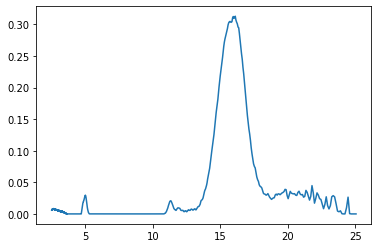

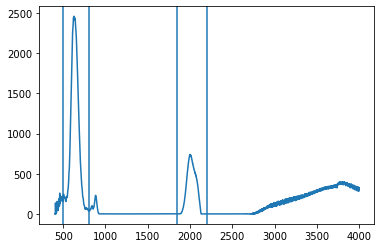

In [16]:
plt.plot(wavelengths, aSi_k(wavelengths))
#plt.plot(wavelengths, Si_k(wavelengths))

plt.figure()
a = 4*np.pi*aSi_k(wavelengths)/ (wavelengths * 1e-4 )
plt.plot(1/wavelengths*1e4, a)
plt.axvline(500)
plt.axvline(800)

plt.axvline(1850)
plt.axvline(2200)

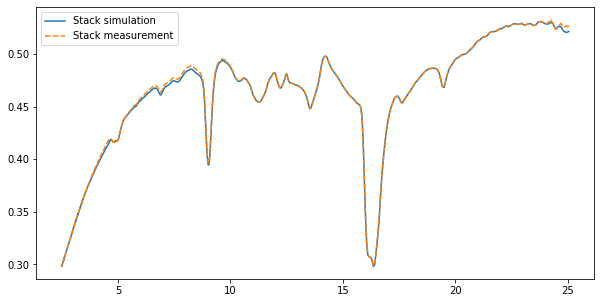

In [17]:
# Simultate total stack with k

c_list = ['i','c', 'i','i']
d_list = [np.inf, 0.246, 525, np.inf] 
def t_total(wavelengths):    
    # 100C: 253, 250C: 238, 350: 261
    T_list = []
    for i, wavelength in enumerate(wavelengths):
        Si = np.complex(Si_n(wavelength), Si_k(wavelength))
        aSi = np.complex(3.4, aSi_k(wavelength))
        n_list = [1, aSi, Si, 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, wavelength)['T'] * scattering_T_tot(wavelength))
    return T_list

fig,ax = plt.subplots(figsize = (10,5))
ax.plot(1e4* 1/wafer_data[:,0], t_total(1e4* 1/wafer_data[:,0]), label='Stack simulation')
ax.plot(1e4* 1/wafer_data[:,0], wafer_data[:,1], label = 'Stack measurement', linestyle = '--')
ax.legend()

In [ ]:
fig,ax = plt.subplots(figsize = (10,5))
ax.plot(1e4* 1/wafer_data[:,0], t_total(1e4* 1/wafer_data[:,0]), label='Stack simulation')
ax.plot(1e4* 1/wafer_data[:,0], wafer_data[:,1], label = 'Stack measurement', linestyle = '--')
ax.legend()

## Calculate hydrogen content

R: 0.2084748963031987
C: 0.1281123900337843


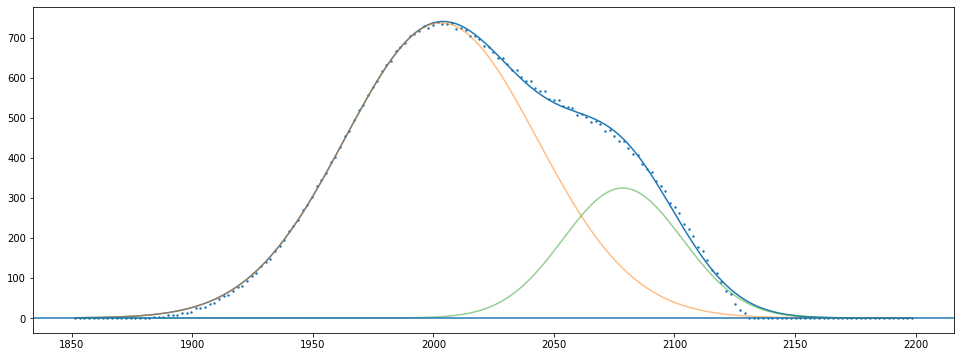

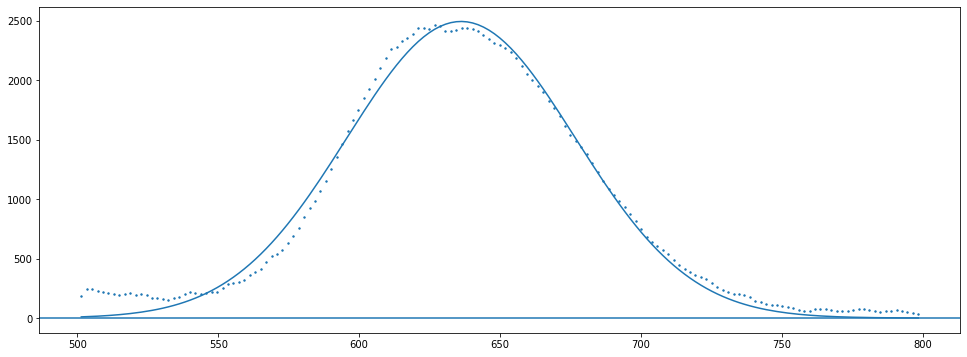

In [25]:
from scipy.integrate import trapz

x = 1/wavelengths*1e4
y = a

peak2_idx = np.logical_and(x > 1850, x < 2200)
peak2_x = x[peak2_idx]
peak2_y = y[peak2_idx]

peak1_idx = np.logical_and(x > 500, x < 800)
peak1_x = x[peak1_idx]
peak1_y = y[peak1_idx]

# Fitting LSM-HSM
def gaussian(x,mu,sigma,a):
    y = a*np.exp(-0.5*((x-mu)/sigma)**2)
    return y

def model(x, mu2000, sigma2000, a2000, mu2080, sigma2080, a2080):
    y = gaussian(x,mu2000,sigma2000,a2000)  + gaussian(x,mu2080,sigma2080,a2080)
    return y

p0 = [2000,30,1e3, 2080,30,1e3]
#bounds = ([1950,0,0, 2050,0,0],[2005,np.inf,np.inf, 2150, np.inf, np.inf])
popt2, pcov2 = curve_fit(model, peak2_x, peak2_y, p0=p0)

fig, ax = plt.subplots(figsize=(16.5,6))
ax.scatter(peak2_x, peak2_y,s=2)
ax.plot(peak2_x, model(peak2_x,*popt2))
ax.plot(peak2_x, gaussian(peak2_x,popt2[0],popt2[1],popt2[2]), alpha=0.5)
ax.plot(peak2_x, gaussian(peak2_x,popt2[3],popt2[4],popt2[5]), alpha=0.5)
ax.axhline(0)

# Fitting content peak
p0 = [640,50,1e3]
#bounds = ([1950,0,0, 2050,0,0],[2005,np.inf,np.inf, 2150, np.inf, np.inf])
popt1, pcov1 = curve_fit(gaussian, peak1_x, peak1_y, p0=p0)

fig, ax = plt.subplots(figsize=(16.5,6))
ax.scatter(peak1_x, peak1_y,s=2)
ax.plot(peak1_x, gaussian(peak1_x,*popt1))
ax.axhline(0)

# Calculate microstructure parameter R
xpoints = np.linspace(np.amin(peak2_x), np.amax(peak2_x), num=1000)
dx = xpoints[1] - xpoints[0]
I_2000 = trapz(gaussian(xpoints,popt2[0],popt2[1],popt2[2])/xpoints, xpoints, dx=dx)
I_2080 = trapz(gaussian(xpoints,popt2[3],popt2[4],popt2[5])/xpoints, xpoints, dx=dx)
R = I_2080/(I_2080 + I_2000)
print('R: ' + str(R))

# Calculate hydrogen content
xpoints = np.linspace(np.amin(peak1_x),np.amax(peak1_x), num=1000)
dx = xpoints[1] - xpoints[0]
A = 1.6*10**19
N = 5*10**22
C = A/N * trapz(gaussian(xpoints,*popt1)/xpoints, xpoints, dx=dx)
print('C: ' + str(C))

## Effect of spectral resolution

In [ ]:
high_res_data = np.loadtxt('/Users/bruno/Library/CloudStorage/iCloud Drive/Thesis/Git/Characterization/FTIR/data/20190619/total_350C_1cm.CSV', delimiter=';')


In [ ]:
fig, ax = plt.subplots(figsize = (400,10))
ax.scatter(high_res_data[:,0], high_res_data[:,1])
ax.plot(high_res_data[:,0], high_res_data[:,1])

In [ ]:
from scipy.ndimage.filters import gaussian_filter1d
fig, ax = plt.subplots(figsize = (5,5))
ax.plot(high_res_data[:,0], gaussian_filter1d(high_res_data[:,1], 4)/100, linestyle = '--' )
ax.plot(data_350C[:,0], data_350C[:,1]*data_background[:,1]/data_empty_holder[:,1]/100)